In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Libraries used:
`statsmodel` - useful for insights.

`scikit-learn` - usefule for predictions.

# Introducing Regression
At its core, regression is a statistical method used to model the relationship between a dependent variable (the outcome you want to predict) and one or more independent variables (the features or predictors).

* Dependent variable/ response variable --> the value to be predicted
* Independent variable/ explanatory variable --> The variables that explain how the dependent variables will change



# Linear Regression

Linear regression is a method to model the relationship between variables by fitting a straight-line equation (or linear combination) that predicts a continuous value.

Modeling the relationship using a linear equation: _`y = mx + b`_ .<br>
here, the **intercept (_b_)** --> is y-value when x=0<br>
and **slope (_m_)** --> the amount by which y-value increases for one increase in _x-value_


### Example: Analyzing an ad spend 
We try to correlate ad spends to the returns on investments in terms of engagement (no. of clicks) on those ads.<br>
Here, ad_spend is the independent/ explanatory variable that explain the dependent/ response variable - no. of clicks.

**Impressions** are the total number of times your content is displayed, no matter if it was clicked or not.<br>
**Reach** is the total number of unique users who see your content.<br>
**Engagement** is the total number of times users interact with your content. This could be likes, comments, shares and **clicks**.

In [2]:
# importing a dataset
cnvrsn_df = pd.read_csv('./datasets/ad_conversion.csv')
cnvrsn_df.head()

,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


First, we plot the ad_spends vs engagement to perform a visual check on the relationship

Using `sns.regplot()` to plot data and draw a linear regression model fit  **that combines a scatter plot of the data points with a best-fit regression line** to visually emphasize patterns & the relationship between two variables (bivariate analysis).

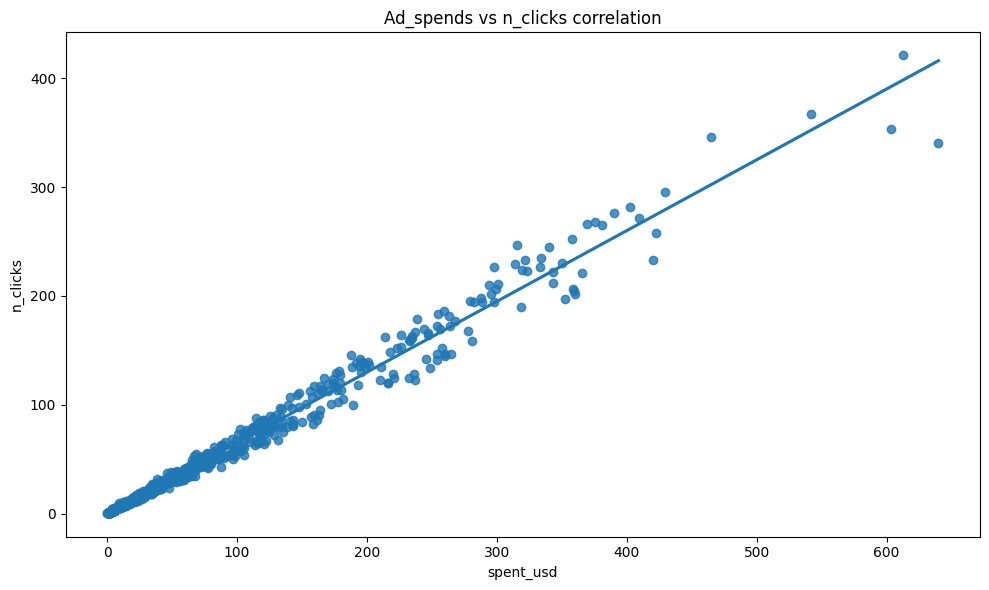

In [3]:
# Visualizing the relationship between the explanatory & response variables
plt.figure(figsize=(10,6))
sns.regplot(data=cnvrsn_df, x='spent_usd' , y='n_clicks', ci=None)
plt.title("Ad_spends vs n_clicks correlation")
plt.tight_layout()
plt.show()

### Running a regression test
What is OLS?

In [4]:
# Importing the OLS module
from statsmodels.formula.api import ols

mdl = ols("spent_usd ~ n_clicks", data= cnvrsn_df)
mdl = mdl.fit()
print(type(mdl))

<class 'statsmodels.regression.linear_model.RegressionResultsWrapper'>


In [5]:
mdl.params

Intercept    0.946359
n_clicks     1.514986
dtype: float64

**Result of the `params` shows that:**

The intercept (_b_) is at 0.95 - This means $0.95 is spent on an ad even when engagement (no. of clicks) is 0.

Slope (_m_) is about 1.5 - for every 1 unit of increase in user engagement (n_clicks), likely expense on ad rises by `(1.5 per n_click)`



In [22]:
mdl_taiwan_hsg_mrkt = ols("price_twd_msq ~ n_convenience" , data = taiwan_hsg_mrkt).fit()
mdl_taiwan_hsg_mrkt.params

Intercept        8.224237
n_convenience    0.798080
dtype: float64

_____
## Linear regression with Categorical ex-variables
In case of >1 explanatory variables that are Categorical, **the coefficients are simply the means of the categories**.

Instead of passing a single Series (one column) as X, you pass a Matrix (multiple columns). statsmodels handles this by calculating the coefficients for every column provided.

Mathematically, the simple linear equation expands to a multidimensional plane (or hyperplane).<br>
So y = mx + b` becomes **y = b + m <sub>1</sub> x + m <sub>2</sub> x + m <sub>3</sub> x + ...**

In [56]:
# Importing the fisheries data
fisheries_df = pd.read_csv("./datasets/fish.csv")
fisheries_df.head(2)

,species,mass_g,length_cm
0,Bream,242.0,23.2
1,Bream,290.0,24.0


In [57]:
# Notice that species is categorical data
print(fisheries_df["species"].nunique())
print(fisheries_df["species"].unique())

4
['Bream' 'Roach' 'Perch' 'Pike']


The dataset basically contains 4 species. Since we have a categorical explanatory variable, visualizing relationship with a scatterplot is not ideal.

Scatterplots are **specifically designed for two continuous variables**. If a continuous variable is plotted against a categorical variable,it'll lead to issues with interpretation, overplotting, and lack of clarity on distributional differences.

As categorical variables have discrete, limited values, a scatterplot will align all data points into vertical or horizontal lines. If the dataset is large, these points will overlap (overplot), making it impossible to see the density of data within each category.

Also, scatterplot shows raw data points, making it difficult to compare mean/ median/ spread or skewness across different categories in a single scatterplot visual.

Thus, it makes sense to use other visualization methods such as plot distribution, box plots etc. to plot distribution of the response variable for each of the categories. `sns.displot` is one such method that can be used for this category-wise distribution mapping. 

<Figure size 1000x800 with 0 Axes>

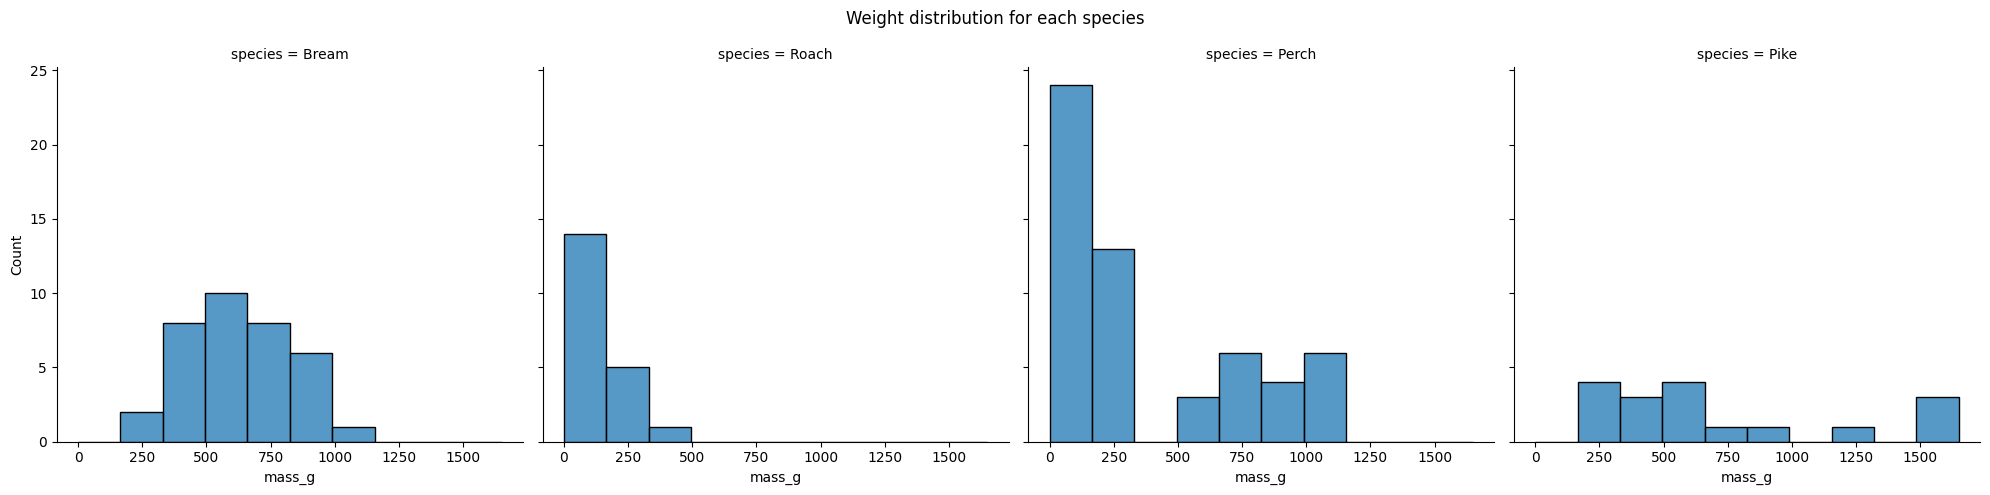

species
Bream    617.83
Perch    382.24
Pike     718.71
Roach    152.05
Name: mass_g, dtype: float64

In [73]:
# Visualizing distribution for each category
plt.figure(figsize = (10,8))
sns.displot(data= fisheries_df, x="mass_g" , col="species", bins=10)
plt.suptitle("Weight distribution for each species")
plt.tight_layout()
plt.show()

# Confirming the visualization using summary stats
fisheries_df.groupby("species")["mass_g"].mean().round(2) 


**If Regression is done with intercept (default):**
* One species is used as the reference category to avoid multicollinearity
* The other coefficients represent differences from the reference<br>
e.g.: `species[Perch] = -235` would mean "Perch weighs 235g less than Bream"

In [46]:
fisheries_mdl = ols("mass_g ~ species", data = fisheries_df).fit()
fisheries_mdl.params

Intercept           617.828571
species[T.Perch]   -235.589286
species[T.Pike]     100.877311
species[T.Roach]   -465.778571
dtype: float64

**Why remove the intercept (+ 0)?**<br>
* All species are kept — no reference category is dropped
* Each coefficient **directly equals the mean mass of that species**<br>
e.g.: `species[Bream] = 617.83` means the average Bream weighs ~618g

>By adding `+ 0` to the `formula`, you're telling `statsmodels` (using the `formula.api` style):<br>
_"Do not use a reference category. Show me the absolute mean for every single group."_

In [53]:
fisheries_mdl = ols("mass_g ~ species + 0", data = fisheries_df).fit()
print(f"Co-efficients after adding 0:\n{fisheries_mdl.params}\n")

# Each coefficient directly equals the mean mass of that species
fisheries_meanmass = fisheries_df.groupby("species")["mass_g"].mean().round(2) 
print(f"Result is same as mean mass of the species:\n{fisheries_meanmass}\n")

Co-efficients after adding 0:
species[Bream]    617.828571
species[Perch]    382.239286
species[Pike]     718.705882
species[Roach]    152.050000
dtype: float64

Result is same as mean mass of the species:
species
Bream    617.83
Perch    382.24
Pike     718.71
Roach    152.05
Name: mass_g, dtype: float64



## Making predictions
Using an explanatory variable to predict value of another variable.

> _"If I set the explanatory variable to some value, what value would response variable have?"_

### Example: from the `fisheries` dataset, using length to predict mass of the fish species

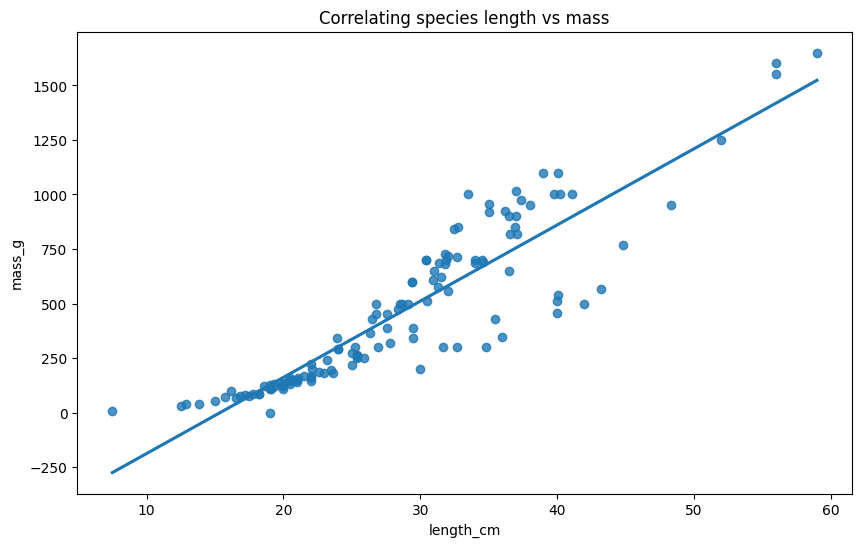

In [90]:
# visualizing relation between length & mass
plt.figure(figsize=(10,6))
sns.regplot(data=fisheries_df, x= "length_cm", y="mass_g", ci=None)
plt.title("Correlating species length vs mass" )
plt.show()

### Step-1: Running the linear regression model for the _Bream_ species

In [94]:
# Creating a df subset for the bream species
bream_sp = fisheries_df[fisheries_df["species"]=="Bream"]
# Running the model for mass vs length
mdl_mass_length = ols("mass_g ~ length_cm", data=bream_sp).fit()

# Checking the coefficients
mdl_mass_length.params

Intercept   -1035.347565
length_cm      54.549981
dtype: float64

### Step-2 Creating a sample df of explanatory data

In [113]:
# Creating sample df containins length calues form 20 - 30 cm
ex_vars = pd.DataFrame({"length_cm": np.arange(20,41)})
ex_vars.head()

,length_cm
0,20
1,21
2,22
3,23
4,24


### Step-3: Using the `predict` method
NOTE: When using the formula API (`ols`), the DataFrame you pass into `.predict()` must **have column names that exactly match** the independent variables used to train the model.

The result in this case will be a pandas series

Add this series & the sample **ex_vars** df, either using `df.assign()` function to a new dataframe OR to existing dataframe to enable comparison alongside the explanatory variables 

In [114]:
# Predicting values based on the linear regression model
mdl_mass_length.predict(ex_vars)

0       55.652054
1      110.202035
2      164.752015
3      219.301996
4      273.851977
5      328.401958
6      382.951939
7      437.501920
8      492.051901
9      546.601882
10     601.151863
11     655.701844
12     710.251825
13     764.801806
14     819.351787
15     873.901768
16     928.451749
17     983.001730
18    1037.551710
19    1092.101691
20    1146.651672
dtype: float64

In [115]:
print(type(mdl_mass_length.predict(ex_vars)))

<class 'pandas.core.series.Series'>


In [116]:
prediction_data = ex_vars.assign(mass_g = mdl_mass_length.predict(ex_vars))
print(prediction_data)
print(type(prediction_data))

    length_cm       mass_g
0          20    55.652054
1          21   110.202035
2          22   164.752015
3          23   219.301996
4          24   273.851977
5          25   328.401958
6          26   382.951939
7          27   437.501920
8          28   492.051901
9          29   546.601882
10         30   601.151863
11         31   655.701844
12         32   710.251825
13         33   764.801806
14         34   819.351787
15         35   873.901768
16         36   928.451749
17         37   983.001730
18         38  1037.551710
19         39  1092.101691
20         40  1146.651672
<class 'pandas.core.frame.DataFrame'>


### Step-4: Visualizing the predictions 
Comparing training & testing data

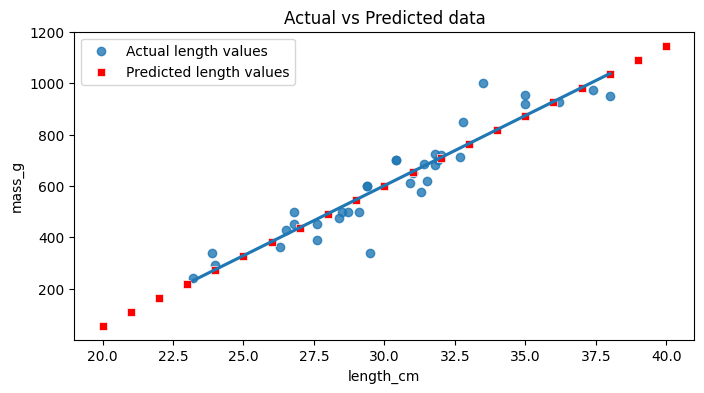

In [134]:
fig = plt.figure(figsize=(8,4))
sns.regplot(x="length_cm", y="mass_g", data=bream_sp, 
            ci=None, label="Actual length values")

sns.scatterplot(data=prediction_data, x="length_cm", y="mass_g", 
                color='red', marker='s', label="Predicted length values")

plt.legend()
plt.title("Actual vs Predicted data")
plt.show()

## Extrapolating predictions


In [138]:
# finding highest length value from species df
bream_sp["length_cm"].max()

np.float64(38.0)

In [139]:
# Predicting species mass for length higher than 38
max_bream_sp = pd.DataFrame({"length_cm": [45]})

max_bream_sp["predicted_len"] = mdl_mass_length.predict(max_bream_sp)
print(max_bream_sp)

   length_cm  predicted_len
0         45    1419.401577


## Model Objects

In [163]:
# Fitted values -- predictions on the original dataset
mdl_mass_length.fittedvalues
# Equivalent to 
mdl_mass_length.predict(bream_sp["length_cm"])

assert mdl_mass_length.fittedvalues.equals(mdl_mass_length.predict(bream_sp["length_cm"]))

In [159]:
# Residual -- difference between actual vs predicted response values 
mdl_mass_length.resid
# Equivalent to 
bream_sp["mass_g"] - mdl_mass_length.fittedvalues

0      11.788007
1      16.148023
2      71.603021
3     -36.316934
4      19.773070
5      23.408076
6      73.408076
7     -80.231909
8     -20.231909
9     -19.326892
10    -38.871893
11    -30.236888
12    -52.056880
13   -233.876873
14     31.578126
15     31.578126
16     77.028145
17     77.028145
18    -40.246846
19     -5.701844
20    -97.066838
21      7.478164
22    -62.976834
23    -19.341829
24     -4.796827
25     25.658171
26      9.748175
27    -34.436811
28     96.108190
29    207.923204
30     46.098232
31     81.098232
32    -14.361745
33    -29.821722
34    -87.551710
dtype: float64

In [164]:
# Residual -- difference between actual vs predicted response values 
mdl_mass_length.resid
# Equivalent to 
bream_sp["mass_g"] - mdl_mass_length.fittedvalues

0      11.788007
1      16.148023
2      71.603021
3     -36.316934
4      19.773070
5      23.408076
6      73.408076
7     -80.231909
8     -20.231909
9     -19.326892
10    -38.871893
11    -30.236888
12    -52.056880
13   -233.876873
14     31.578126
15     31.578126
16     77.028145
17     77.028145
18    -40.246846
19     -5.701844
20    -97.066838
21      7.478164
22    -62.976834
23    -19.341829
24     -4.796827
25     25.658171
26      9.748175
27    -34.436811
28     96.108190
29    207.923204
30     46.098232
31     81.098232
32    -14.361745
33    -29.821722
34    -87.551710
dtype: float64

In [166]:
mdl_mass_length.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 mass_g   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.874
Method:                 Least Squares   F-statistic:                     237.6
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.22e-16
Time:                        21:03:36   Log-Likelihood:                -199.35
No. Observations:                  35   AIC:                             402.7
Df Residuals:                      33   BIC:                             405.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1035.3476    107.973     -9.589      0.000   -1255.020    -815.676
length_cm     54.5500      3.539     15.415      0.000      47.350      61.750
==============================================================================
Omnibus:                        7.314   Durbin-Watson:                   1.478
Prob(Omnibus):                  0.026   Jarque-Bera (JB):               10.857
Skew:                          -0.252   Prob(JB):                      0.00439
Kurtosis:                       5.682   Cond. No.                         263.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Regression to mean
Regression to the Mean (RTTM) is a statistical phenomenon where, if a variable is extreme on its first measurement, it will tend to be closer to the average (the mean) on its second measurement.

### Why it Matters in Data Science
If you are running a regression model and you see a massive spike or drop in your data, you have to ask: Is this a new trend, or is it just regression to the mean?

___
# Linear Regression-Example dataset-Taiwan housing dataset:

In [63]:
# Importing the dataset for Taiwan housing market
taiwan_hsg_mrkt = pd.read_csv('./datasets/taiwan_real_estate2.csv')
taiwan_hsg_mrkt.head()

,dist_to_mrt_m,n_convenience,house_age_years,price_twd_msq
0,84.87882,10,30 to 45,11.467474
1,306.59470,9,15 to 30,12.768533
2,561.98450,5,0 to 15,14.311649
3,561.98450,5,0 to 15,16.580938
4,390.56840,5,0 to 15,13.040847


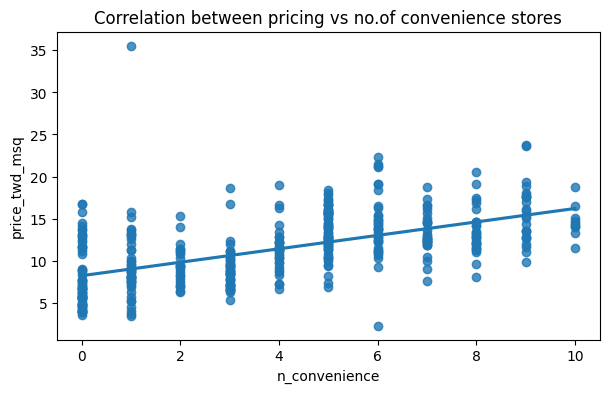

In [107]:
# Observing the pricing-no. of stores relationship
plt.figure(figsize = (7,4))
sns.regplot(data=taiwan_hsg_mrkt, x= "n_convenience", y="price_twd_msq", ci=None)
plt.title("Correlation between pricing vs no.of convenience stores")
plt.show()

The `params` result shows that:
* The intercept (b) is 8.22 - This is **price per sq.m even when there's no convenience store nearby**
* The slope (m) is 0.79 - This is the **rate of increase in pricing per sq.m when no. of nearby store increased by 1**

___
**Q** :<br>
The Taiwan real estate dataset has a categorical variable in the form of the age of each house.<br>
The ages have been split into 3 groups: 0 to 15 years, 15 to 30 years, and 30 to 45 years.

 Since the independent variable is a categorical, a good option is to draw a histogram for each category.<br>
Plot a histogram of `price_twd_msq` with 10 bins. Split the plot by `house_age_years` to give 3 panels.

**Ans** : <br>
It appears that new houses are the most expensive on average, and the medium aged ones (15 to 30 years) are the cheapest.

<Figure size 1000x800 with 0 Axes>

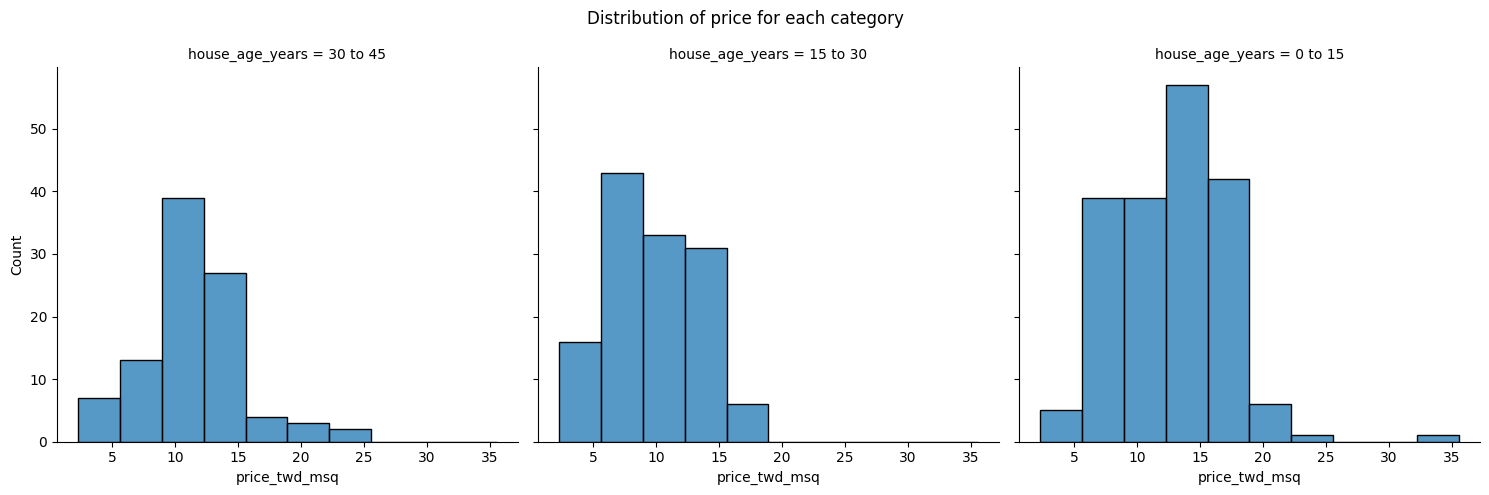

In [77]:
plt.figure(figsize=(10,8))
# Histograms of price_twd_msq with 10 bins, split by the age of each house
sns.displot(data=taiwan_hsg_mrkt,  x="price_twd_msq",  col="house_age_years", bins=10)
# Show the plot
plt.suptitle("Distribution of price for each category")
plt.tight_layout()
plt.show()

**Q**:<br>
Prove that the coefficients of a linear regression model with one categorical variable are the means of each category. 

**Ans**:<br>
The coefficients of the model are just the means of each category, verified by the groupby aggregation.


In [78]:
taiwan_hsg_mrkt.groupby("house_age_years")["price_twd_msq"].mean()

house_age_years
0 to 15     12.637471
15 to 30     9.876743
30 to 45    11.393264
Name: price_twd_msq, dtype: float64

In [79]:
mdl_twn_price_vsage = ols("price_twd_msq ~ house_age_years + 0", data=taiwan_hsg_mrkt).fit()
mdl_twn_price_vsage.params

house_age_years[0 to 15]     12.637471
house_age_years[15 to 30]     9.876743
house_age_years[30 to 45]    11.393264
dtype: float64

**Q**:<br>
Make predictions for the house prices in the Taiwan real estate dataset. <br>
`mdl_taiwan_hsg_mrkt` is the fitted linear regression model of house price versus number of convenience stores.<br>
Create a sample df of explanatory data, where n_convenience has values from zero to ten.<br>
Lastly, visualize the predictions against training data.

In [141]:
# Create explanatory_data 
explanatory_data = pd.DataFrame({'n_convenience': np.arange(0, 11)})
# Use mdl_price_vs_conv to predict with explanatory_data, call it price_twd_msq
price_twd_msq = mdl_taiwan_hsg_mrkt.predict(explanatory_data)
# Create prediction_data
prediction_data = explanatory_data.assign(price_twd_msq = price_twd_msq)
# Print the result
print(prediction_data)

    n_convenience  price_twd_msq
0               0       8.224237
1               1       9.022317
2               2       9.820397
3               3      10.618477
4               4      11.416556
5               5      12.214636
6               6      13.012716
7               7      13.810795
8               8      14.608875
9               9      15.406955
10             10      16.205035


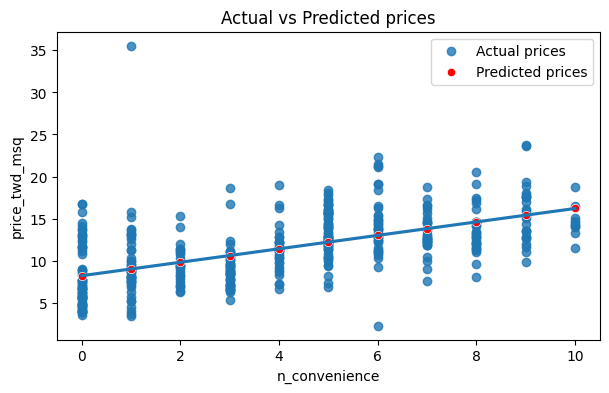

In [144]:
# Create a new figure, fig
fig = plt.figure(figsize=(7,4))
sns.regplot(x="n_convenience", y="price_twd_msq", data=taiwan_hsg_mrkt, ci=None, label="Actual prices")
# Add a scatter plot layer to the regplot
sns.scatterplot(data=prediction_data, x="n_convenience",y="price_twd_msq", color='red', label="Predicted prices")
plt.title("Actual vs Predicted prices")
# Show the layered plot
plt.show()

____
# Logistic Regression